In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
import os
from google.colab import drive

# 1. Mount Drive if you haven't already
drive.mount('/content/drive')

# 2. Create a specific folder in your Drive for this project
drive_path = "/content/drive/MyDrive/Spectra_YOLO_Project"
os.makedirs(drive_path, exist_ok=True)

# 3. Create a SYMLINK (The Magic Step)
# This tells Colab: "When you think you're saving to /content/runs, actually save to my Drive"
!rm -rf /content/runs
!ln -s /content/drive/MyDrive/Spectra_YOLO_Project /content/runs

print("✅ Shortcut created! Your progress will now save to Google Drive in real-time.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Shortcut created! Your progress will now save to Google Drive in real-time.


In [ ]:

# Create a local folder on the Colab disk (much faster than reading from Drive directly)
!mkdir -p datasets
!unzip -q /content/drive/MyDrive/Spectra/yolo_dataset.zip -d datasets/

In [ ]:
from ultralytics import YOLO

# Load model
model = YOLO("yolo11n.pt")

# Train on T4 GPU
# We can use a larger imgsz (640) and batch (32) because T4 has 16GB VRAM
model.train(
    data="/content/drive/MyDrive/Spectra/charts.yaml",
    epochs=10,
    imgsz=640,
    batch=32,
    device=0, # 0 is the index for the T4 GPU
    amp=True
)

Streaming output truncated to the last 5000 lines.
val: /content/datasets/yolo_dataset/images/val/14263.png: ignoring corrupt image/label: negative class labels or coordinate [  -0.015492   -0.026336]
val: /content/datasets/yolo_dataset/images/val/14268.png: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0863      1.0932      1.1128      1.1277      1.1266      1.0863]
val: /content/datasets/yolo_dataset/images/val/14269.png: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.2485]
val: /content/datasets/yolo_dataset/images/val/14272.png: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.1328      1.0808      1.0557      1.0826      1.1096]
val: /content/datasets/yolo_dataset/images/val/14275.png: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.1009]
val: /content/datasets/yolo_dataset/images/val/14276.png: ignoring corrupt image/label: non-normalized or o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f1f7f174b60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



image 1/1 /content/datasets/yolo_dataset/images/val/two_col_104136.png: 448x640 5 bars, 17.8ms
Speed: 2.9ms preprocess, 17.8ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)


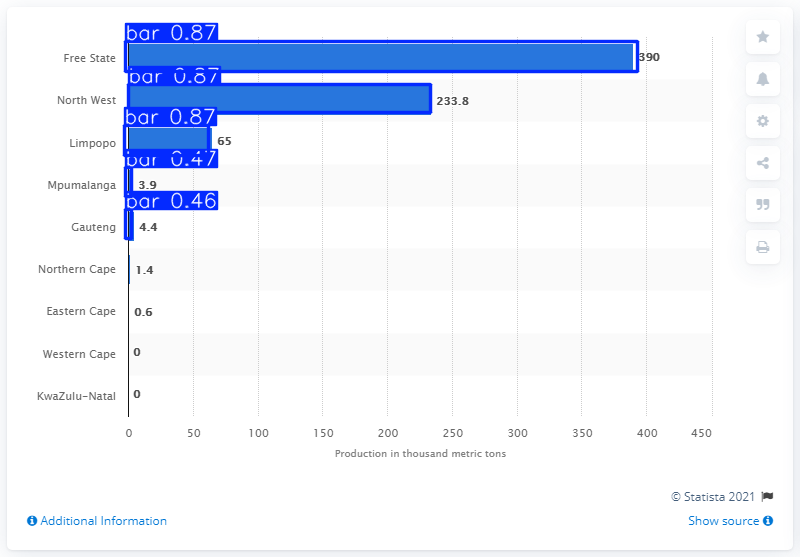

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# 1. Load your best weights from the 10 epochs
model = YOLO('/content/drive/MyDrive/Spectra_YOLO_Project/detect/train/weights/best.pt')

# 2. Run it on ONE image from your val set
results = model.predict(source='/content/datasets/yolo_dataset/images/val/two_col_104136.png', conf=0.25)

# 3. Show the result
annotated_frame = results[0].plot()
cv2_imshow(annotated_frame)

In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 19.9 MB/s eta 0:00:00


In [ ]:
import cv2
import easyocr
import numpy as np
import pandas as pd
import re

IMAGE_PATH = '/content/datasets/yolo_dataset/images/val/two_col_104136.png'
reader = easyocr.Reader(['en'], gpu=True)
img = cv2.imread(IMAGE_PATH)

results = model.predict(source=IMAGE_PATH, conf=0.25)
boxes = results[0].boxes.xyxy.cpu().tolist()
boxes = sorted(boxes, key=lambda b: b[0])

# --- MODULE A: ROBUST MEDIAN Y-AXIS SCALE ---
left_bar_x = int(boxes[0][0])
bottom_of_chart = max([int(b[3]) for b in boxes])
y_axis_crop = img[0:bottom_of_chart, 0:left_bar_x]

print("Reading Y-Axis...")
y_ocr_results = reader.readtext(y_axis_crop)

y_numbers = []
for (bbox, text, prob) in y_ocr_results:
    clean_text = re.sub(r'[^\d.]', '', text)
    if clean_text:
        y_center = (bbox[0][1] + bbox[2][1]) / 2
        y_numbers.append({'value': float(clean_text), 'y_pixel': y_center})

pixels_per_unit = 0

if len(y_numbers) >= 2:
    y_numbers = sorted(y_numbers, key=lambda x: x['y_pixel'])
    scales = []
    for i in range(len(y_numbers)-1):
        for j in range(i+1, len(y_numbers)):
            val_diff = abs(y_numbers[i]['value'] - y_numbers[j]['value'])
            pix_diff = abs(y_numbers[i]['y_pixel'] - y_numbers[j]['y_pixel'])
            if val_diff > 0:
                scales.append(pix_diff / val_diff)

    if scales:
        pixels_per_unit = np.median(scales)
        print(f"Robust Scale Found: 1 unit = {pixels_per_unit:.2f} pixels.")

# --- MODULE B: LABELS, RAYCASTING & MATH ---
# --- MODULE: ABSOLUTE PREDICTION WITHOUT TOP-TEXT ---
print("Predicting Absolute Values via Y-Axis Scale...")
final_data = []

# pixels_per_unit was calculated in Module A from the Y-Axis labels
for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    cx = (x1 + x2) // 2

    # 1. RAYCASTING: Find the real top of the bar visually
    sample_y = int(y2 - 5)
    bar_color = img[sample_y, cx].astype(int)
    true_y1 = y1

    for y_search in range(sample_y, 0, -1):
        color_diff = np.sum(np.abs(img[y_search, cx].astype(int) - bar_color))
        if color_diff > 60: # Threshold for background color change
            true_y1 = y_search
            break

    # 2. CALCULATION: Units = (Bottom_Pixel - Top_Pixel) / Scale
    full_pixel_height = y2 - true_y1

    if pixels_per_unit > 0:
        predicted_absolute_value = full_pixel_height / pixels_per_unit
    else:
        predicted_absolute_value = 0 # Fallback if Y-axis scale failed

    # 3. CATEGORY OCR (X-Axis)
    label_crop = img[y2:min(img.shape[0], y2+35), max(0, cx-25):min(img.shape[1], cx+25)]
    label_results = reader.readtext(label_crop, detail=0, allowlist='0123456789')
    category = label_results[0] if label_results else "Unknown"

    final_data.append({
        "Year": category,
        "Predicted_Value": round(predicted_absolute_value, 2),
        "Measured_Pixels": full_pixel_height
    })

df = pd.DataFrame(final_data)
print(df.to_string(index=False))


image 1/1 /content/datasets/yolo_dataset/images/val/two_col_104136.png: 448x640 5 bars, 13.0ms
Speed: 2.0ms preprocess, 13.0ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Reading Y-Axis...
Predicting Absolute Values via Y-Axis Scale...
   Year  Predicted_Value  Measured_Pixels
Unknown                0               28
Unknown                0              202
Unknown                0              160
Unknown                0               28
Unknown                0               27


In [ ]:
!unzip -q /content/drive/MyDrive/Spectra/yolo_dataset_bar.zip -d /content/datasets/

In [ ]:
import yaml

# Path to the local Colab directory where you just unzipped the data
config = {
    'train': '/content/datasets/yolo_dataset_bar/images/train',
    'val': '/content/datasets/yolo_dataset_bar/images/val',
    'nc': 1,
    'names': ['bar']
}

with open('/content/charts.yaml', 'w') as f:
    yaml.dump(config, f)

Verifying: /content/datasets/yolo_dataset_bar/images/train/40148.png


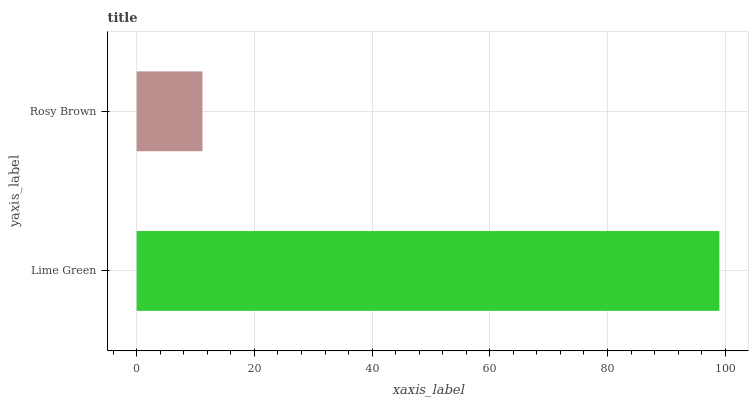

In [ ]:
import cv2
import os
from google.colab.patches import cv2_imshow

# View a random training image to verify labels
img_list = os.listdir('/content/datasets/yolo_dataset_bar/images/train')
sample_img_path = f'/content/datasets/yolo_dataset_bar/images/train/{img_list[77]}'
img = cv2.imread(sample_img_path)

print(f"Verifying: {sample_img_path}")
cv2_imshow(img)

Verifying Labels for: 30430.png


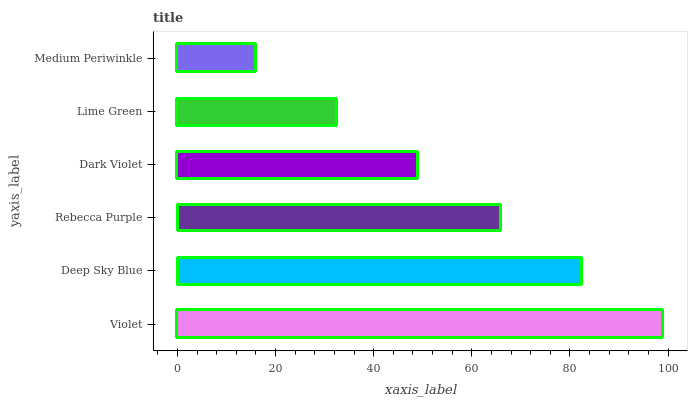

In [ ]:
import cv2
import os
import random
from google.colab.patches import cv2_imshow

def verify_yolo_labels(img_dir, label_dir):
    # Get list of images
    images = [f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    sample_img = random.choice(images)
    sample_label = sample_img.rsplit('.', 1)[0] + '.txt'

    img_path = os.path.join(img_dir, sample_img)
    label_path = os.path.join(label_dir, sample_label)

    if not os.path.exists(label_path):
        print(f"No label found for {sample_img}")
        return

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.split()
            # YOLO format: class cx cy nw nh
            cx, cy, nw, nh = map(float, parts[1:])

            # Convert normalized back to pixel coordinates
            x1 = int((cx - nw/2) * w)
            y1 = int((cy - nh/2) * h)
            x2 = int((cx + nw/2) * w)
            y2 = int((cy + nh/2) * h)

            # Draw the box (Green)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    print(f"Verifying Labels for: {sample_img}")
    cv2_imshow(img)

# RUN IT
verify_yolo_labels('/content/datasets/yolo_dataset_bar/images/train',
                   '/content/datasets/yolo_dataset_bar/labels/train')

In [ ]:
import os
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Updated path for the new Clean Bar Project
# Saving to a subfolder called 'Clean_Bar_Run' so you don't overwrite old trials
drive_path = "/content/drive/MyDrive/Spectra_YOLO_Project/Clean_Bar_Run"
os.makedirs(drive_path, exist_ok=True)

# 3. Create the Symlink
# Now, any weights saved by YOLO will physically exist on your Google Drive
!rm -rf /content/runs
!ln -s /content/drive/MyDrive/Spectra_YOLO_Project/Clean_Bar_Run /content/runs

print(f"✅ Savepoint active! Weights will be at: {drive_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Savepoint active! Weights will be at: /content/drive/MyDrive/Spectra_YOLO_Project/Clean_Bar_Run


In [ ]:
import torch
from ultralytics import YOLO

# Check if GPU is actually connected
if not torch.cuda.is_available():
    print("❌ ERROR: GPU not found! Go to Runtime > Change runtime type > T4 GPU")
else:
    print(f"✅ GPU Found: {torch.cuda.get_device_name(0)}")

    # Load fresh model
    model = YOLO("yolo11n.pt")

    # Start Training with Hyperparameter Safety Nets
    model.train(
        data="/content/charts.yaml",
        epochs=30,
        imgsz=640,
        batch=32,
        device=0,
        overlap_mask=False,

        # --- THE STABILITY FIXES ---
        optimizer='AdamW',  # A much more stable optimizer than the default
        lr0=0.001,          # Lower maximum learning rate (prevents the explosion)
        warmup_epochs=2,    # Shorten the warmup period
    )

✅ GPU Found: Tesla T4
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/charts.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=False, patience=10

In [ ]:
from google.colab import drive
import os

# 1. Mount Google Drive to the Colab environment
drive.mount('/content/drive')

# 2. Create the exact backup folder structure you requested
drive_save_path = "/content/drive/MyDrive/Spectra_YOLO_Project/dot_line"
os.makedirs(drive_save_path, exist_ok=True)
print(f"✅ Drive backup folder ready at: {drive_save_path}")

# 3. Unzip the dataset into Colab's fast local storage
# 👇 UPDATE THIS TO MATCH THE EXACT NAME OF YOUR ZIP FILE ON DRIVE 👇
zip_file_path = "/content/drive/MyDrive/Spectra/yolo_dataset_dots.zip"
extraction_path = "/content/datasets"

print("📦 Unzipping dataset... (this might take a minute)")
!unzip -q "{zip_file_path}" -d "{extraction_path}"
print("✅ Dataset successfully unzipped into Colab!")

Mounted at /content/drive
✅ Drive backup folder ready at: /content/drive/MyDrive/Spectra_YOLO_Project/dot_line
📦 Unzipping dataset... (this might take a minute)
✅ Dataset successfully unzipped into Colab!


In [ ]:
pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 36.7 MB/s eta 0:00:00


In [ ]:
import torch
from ultralytics import YOLO

# 1. Create the dataset configuration file
# Note: Adjust the paths if your zip file extracted slightly differently!
yaml_content = """
train: /content/datasets/yolo_dataset_dots/images/train
val: /content/datasets/yolo_dataset_dots/images/val
nc: 1
names: ['dot']
"""

with open("/content/dots.yaml", "w") as f:
    f.write(yaml_content.strip())

print("✅ Configuration saved. Booting up AI training...\n")

# 2. Start Local Training
model = YOLO("yolo11n.pt")

model.train(
    data="/content/dots.yaml",
    epochs=25,
    imgsz=640,
    batch=32,
    device=0,
    optimizer='AdamW',
    lr0=0.001,

    # 🛡️ THE SAFETY NET: Save progress directly to Google Drive
    project="/content/drive/MyDrive/Spectra_YOLO_Project/dot_line",
    name="dot_detector_run",

    save=True,
    save_period=5  # Forces a hard backup of the weights every 5 epochs
)

print("✅ Dot Constellation Training Complete! Your weights are safely in Google Drive.")

Streaming output truncated to the last 5000 lines.
train: /content/datasets/yolo_dataset_dots/images/train/FigureQA_94924.png: 4 duplicate labels removed
train: /content/datasets/yolo_dataset_dots/images/train/FigureQA_94929.png: 5 duplicate labels removed
train: /content/datasets/yolo_dataset_dots/images/train/FigureQA_94930.png: 1 duplicate labels removed
train: /content/datasets/yolo_dataset_dots/images/train/FigureQA_94932.png: 5 duplicate labels removed
train: /content/datasets/yolo_dataset_dots/images/train/FigureQA_94934.png: 1 duplicate labels removed
train: /content/datasets/yolo_dataset_dots/images/train/FigureQA_94939.png: 2 duplicate labels removed
train: /content/datasets/yolo_dataset_dots/images/train/FigureQA_94944.png: 2 duplicate labels removed
train: /content/datasets/yolo_dataset_dots/images/train/FigureQA_94945.png: 1 duplicate labels removed
train: /content/datasets/yolo_dataset_dots/images/train/FigureQA_94946.png: 4 duplicate labels removed
train: /content/datase

🧠 Loading STEM Sight Dot Detector...
🔍 Inspecting: /content/datasets/yolo_dataset_dots/images/val/FigureQA_1790.png

image 1/1 /content/datasets/yolo_dataset_dots/images/val/FigureQA_1790.png: 480x640 85 dots, 50.4ms
Speed: 2.6ms preprocess, 50.4ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


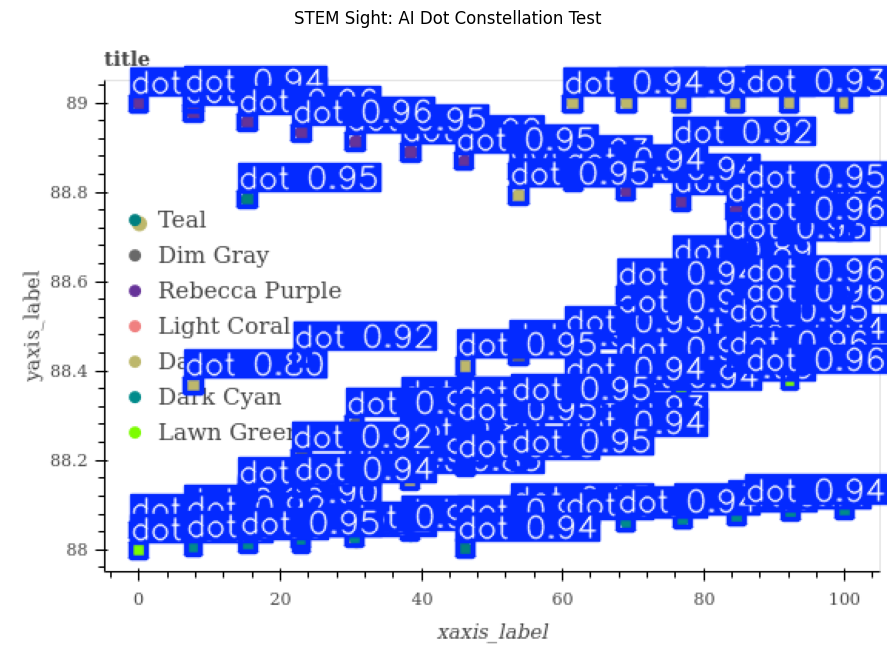

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random
from ultralytics import YOLO

# 1. Load your newly trained "Brain"
model_path = "/content/drive/MyDrive/Spectra_YOLO_Project/dot_line/dot_detector_run/weights/best.pt"
print("🧠 Loading STEM Sight Dot Detector...")
dot_model = YOLO(model_path)

# 2. Pick a random test image from the validation set
val_dir = "/content/datasets/yolo_dataset_dots/images/val"
test_images = [f for f in os.listdir(val_dir) if f.endswith(('.png', '.jpg'))]
test_image_path = os.path.join(val_dir, random.choice(test_images))

print(f"🔍 Inspecting: {test_image_path}")

# 3. Run AI Inference (Find the dots!)
# We use conf=0.5 to only show dots it is at least 50% confident about
results = dot_model(test_image_path, conf=0.5)

# 4. Draw and Display the Results
annotated_img = results[0].plot()
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_img_rgb)
plt.title("STEM Sight: AI Dot Constellation Test")
plt.axis('off')
plt.show()

🧠 Booting up STEM Sight Audio-Optimized Engine...

🚀 Analyzing: /content/datasets/yolo_dataset_dots/images/val/FigureQA_5645.png
----------------------------------------
✅ Extraction Complete! (Ready for Audio Engine)

🔵 Line: RGB(100, 0, 0)
  Point_1: 9.28
  Point_2: 9.23
  Point_3: 9.15
  Point_4: 9.08
  Point_5: 9.03
  Point_6: 8.92
  Point_7: 8.87
  Point_8: 8.82
  Point_9: 8.72

🔵 Line: RGB(150, 200, 50)
  Point_1: 0.38
  Point_2: 0.47
  Point_3: 0.52
  Point_4: 0.52
  Point_5: 0.47
  Point_6: 0.37
  Point_7: 0.22
  Point_8: 0.01
  Point_9: -0.9
  Point_10: -1.3
  Point_11: -1.76

🔵 Line: RGB(200, 100, 200)
  Point_1: -2.62
  Point_2: -2.08
  Point_3: -1.51
  Point_4: -0.95
  Point_5: 0.12
  Point_6: 0.68
  Point_7: 1.23

🔵 Line: RGB(0, 250, 0)
  Point_1: -3.92
  Point_2: -3.38
  Point_3: -3.08
  Point_4: -3.12
  Point_5: -3.48
  Point_6: -4.09
  Point_7: -4.9
  Point_8: -5.41

🔵 Line: RGB(150, 150, 150)
  Point_1: -4.66
  Point_2: -3.47
  Point_3: -2.52
  Point_4: -1.86
  Point_5

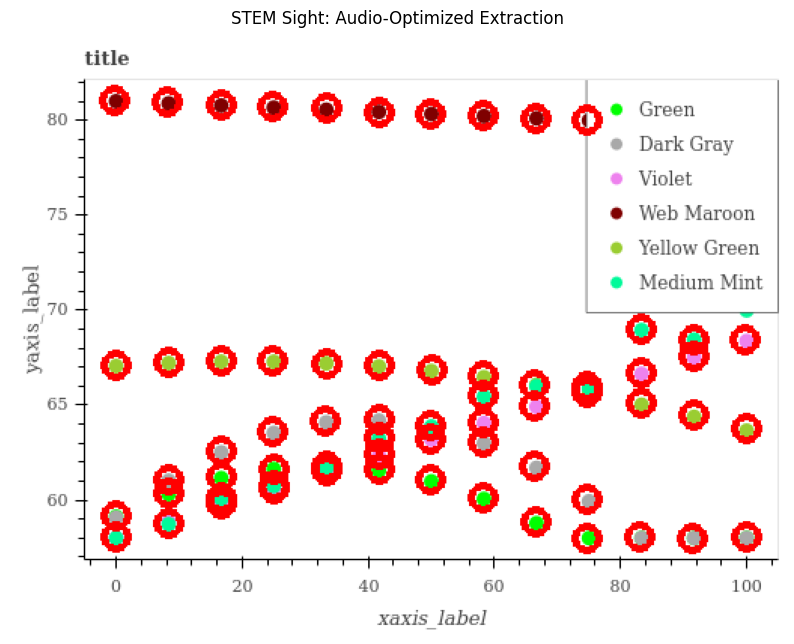

In [ ]:
import cv2
import numpy as np
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO
import warnings
import random
import os
import re

warnings.filterwarnings("ignore")

print("🧠 Booting up STEM Sight Audio-Optimized Engine...")
yolo_dot_model = YOLO("/content/drive/MyDrive/Spectra_YOLO_Project/dot_line/dot_detector_run/weights/best.pt")
ocr_reader = easyocr.Reader(['en'], gpu=True)

def extract_dot_line_data(image_path):
    print(f"\n🚀 Analyzing: {image_path}")
    print("-" * 40)

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w, _ = img.shape
    failed = False

    # --- STEP 1: YOLO DOT DETECTION ---
    results = yolo_dot_model(image_path, conf=0.5, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    if len(boxes) == 0:
        print("❌ No dots detected.")
        return None

    dots = []
    for box in boxes:
        x1, y1, x2, y2 = box
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        patch = img_rgb[int(cy)-1:int(cy)+2, int(cx)-1:int(cx)+2]
        avg_color = np.median(patch, axis=(0,1))

        # 🔥 THE ARTIFACT SLAYER: Ignore white/light-gray background dots
        if avg_color[0] > 200 and avg_color[1] > 200 and avg_color[2] > 200:
            continue

        color_group = f"RGB({int(avg_color[0]//50*50)}, {int(avg_color[1]//50*50)}, {int(avg_color[2]//50*50)})"
        dots.append({'cx': cx, 'cy': cy, 'color': color_group})

    min_dot_x = min(d['cx'] for d in dots) if dots else 0
    max_dot_y = max(d['cy'] for d in dots) if dots else 0

    # --- STEP 2: HIGH-CONTRAST OCR (Y-Axis Only Focus) ---
    ocr_results = ocr_reader.readtext(
        image_path,
        mag_ratio=3,
        contrast_ths=0.1,
        adjust_contrast=0.5
    )

    y_axis_nums = []

    for (bbox, text, prob) in ocr_results:
        tcx = (bbox[0][0] + bbox[1][0]) / 2
        tcy = (bbox[0][1] + bbox[2][1]) / 2
        clean_text = text.lower()

        forbidden = ["axis", "label", "title", "blue", "red", "green", "yellow", "purple", "orange", "pink", "brown", "black", "white", "gray", "cyan", "magenta", "dodger"]
        if any(word in clean_text for word in forbidden): continue

        numbers_found = re.findall(r"[-+]?\d*\.\d+|\d+", text)

        # We only care about establishing the Y-scale math
        if tcx < min_dot_x + 15 and numbers_found:
            y_axis_nums.append({'val': float(numbers_found[0]), 'x': tcx, 'y': tcy})

    # --- STEP 3: Y-AXIS SCALE MATH ---
    y_axis_nums = sorted(y_axis_nums, key=lambda d: d['y'], reverse=True)
    unique_y = []
    for y in y_axis_nums:
        if not unique_y or abs(unique_y[-1]['val'] - y['val']) > 0:
            unique_y.append(y)

    if len(unique_y) >= 2:
        base_y = unique_y[0]['y']
        base_val = unique_y[0]['val']
        top_y = unique_y[-1]['y']
        top_val = unique_y[-1]['val']

        pixel_diff = abs(top_y - base_y)
        units_per_pixel = abs(top_val - base_val) / pixel_diff if pixel_diff > 5 else 0
    else:
        print("❌ OCR failed to find Y-Axis bounds.")
        return None

    # --- STEP 4: INDEPENDENT LINE SORTING (AUDIO OPTIMIZED) ---
    extracted_data = {}

    # First, group all dots by their physical color
    for dot in dots:
        pixel_height = base_y - dot['cy']
        real_value = base_val + (pixel_height * units_per_pixel)

        line_name = dot['color']
        if line_name not in extracted_data: extracted_data[line_name] = []
        # Store the X-pixel so we can sort them later
        extracted_data[line_name].append({'cx': dot['cx'], 'y_val': round(real_value, 2)})

    # Now, process each line independently
    final_audio_sequence = {}
    print("✅ Extraction Complete! (Ready for Audio Engine)")

    for line_color, points in extracted_data.items():
        print(f"\n🔵 Line: {line_color}")
        final_audio_sequence[line_color] = []

        # Sort this specific line's dots perfectly from left to right
        sorted_points = sorted(points, key=lambda p: p['cx'])

        for i, point in enumerate(sorted_points):
            category = f"Point_{i+1}"
            val = point['y_val']
            final_audio_sequence[line_color].append((category, val))
            print(f"  {category}: {val}")

    # --- DRAW THE IMAGE ---
    plt.figure(figsize=(10, 8))
    for dot in dots:
        cv2.circle(img_rgb, (int(dot['cx']), int(dot['cy'])), 8, (255, 0, 0), 3)
    plt.imshow(img_rgb)
    plt.title("STEM Sight: Audio-Optimized Extraction")
    plt.axis('off')
    plt.show()

    return final_audio_sequence

# Run it on that exact same broken image!
test_image = "/content/datasets/yolo_dataset_dots/images/val/FigureQA_5645.png"
if os.path.exists(test_image):
    final_output = extract_dot_line_data(test_image)